In [1]:
import zipfile
import os
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
import pandas as pd
#from surprise import Dataset, Reader, SVD
#from surprise.model_selection import train_test_split
#from surprise import accuracy

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
ml_32m_folder = "/kaggle/input/ml-32m/ml-32m"
  # change if needed

# ----------------------------------------
# List all CSV files in the folder
# ----------------------------------------
csv_files = [f for f in os.listdir(ml_32m_folder) if f.endswith(".csv")]
print("Found CSV files:", csv_files)

# ----------------------------------------
# Load all CSV files
# ----------------------------------------
dataframes = {}

for file in csv_files:
    full_path = os.path.join(ml_32m_folder, file)
    df_name = file.replace('.csv', '')
    dataframes[df_name] = pd.read_csv(full_path)
    print(f"✔ Loaded: {df_name} ({len(dataframes[df_name])} rows)")

# ----------------------------------------
# Print .head() for each dataframe
# ----------------------------------------
print("\n========== DATA PREVIEW ==========\n")
for name, df in dataframes.items():
    print(f"\n🔹 {name}.head():")
    print(df.head())

Found CSV files: ['ratings.csv', 'tags.csv', 'movies.csv', 'links.csv', 'movies_enriched.csv']
✔ Loaded: ratings (32000204 rows)
✔ Loaded: tags (2000072 rows)
✔ Loaded: movies (87585 rows)
✔ Loaded: links (87585 rows)
✔ Loaded: movies_enriched (86315 rows)

========== DATA PREVIEW ==========


🔹 ratings.head():
   userId  movieId  rating  timestamp
0       1       17     4.0  944249077
1       1       25     1.0  944250228
2       1       29     2.0  943230976
3       1       30     5.0  944249077
4       1       32     5.0  943228858

🔹 tags.head():
   userId  movieId          tag   timestamp
0      22    26479  Kevin Kline  1583038886
1      22    79592     misogyny  1581476297
2      22   247150   acrophobia  1622483469
3      34     2174        music  1249808064
4      34     2174        weird  1249808102

🔹 movies.head():
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3 

In [4]:
movies = dataframes["movies"]
ratings = dataframes["ratings"]
tags = dataframes["tags"]
links = dataframes["links"]



,rating
count,3.200020e+07
mean,3.540396e+00
std,1.058986e+00
min,5.000000e-01
25%,3.000000e+00
50%,3.500000e+00
75%,4.000000e+00
max,5.000000e+00


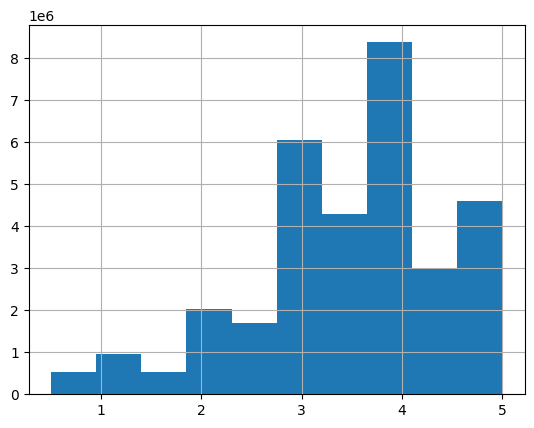

In [5]:
ratings['rating'].hist(bins=10)
ratings['rating'].describe()


In [6]:
movie_counts = ratings['movieId'].value_counts()
movie_counts.describe()


,count
count,84432.000000
mean,379.005638
std,2592.439791
min,1.000000
25%,2.000000
50%,5.000000
75%,25.000000
max,102929.000000


In [7]:
movie_counts.head()


,count
movieId,
318,102929
356,100296
296,98409
2571,93808
593,90330


In [8]:
movie_counts.tail()

,count
movieId,
206505,1
229167,1
138948,1
121961,1
137537,1


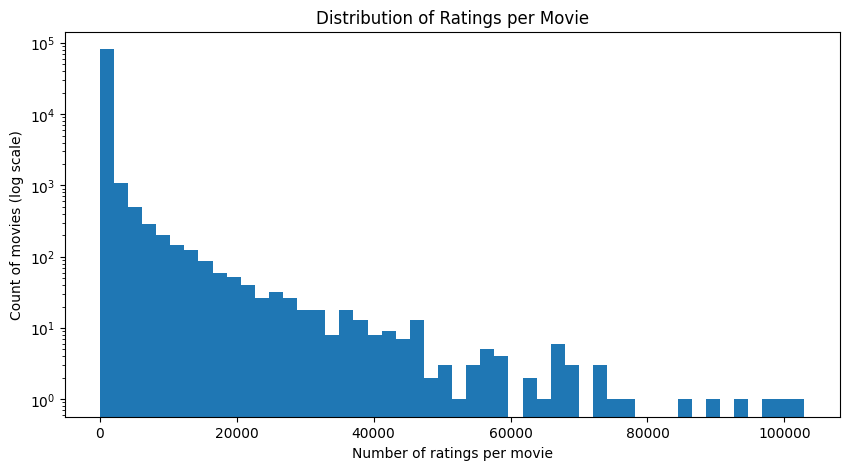

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
plt.hist(movie_counts, bins=50, log=True)
plt.xlabel("Number of ratings per movie")
plt.ylabel("Count of movies (log scale)")
plt.title("Distribution of Ratings per Movie")
plt.show()


In [10]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
sparsity = 1 - (len(ratings) / (n_users * n_movies))


In [ ]:
sparsity

0.9981139118693746

In [11]:
movies['genres'].str.split('|').explode().value_counts()


,count
genres,
Drama,34175
Comedy,23124
Thriller,11823
Romance,10369
Action,9668
Documentary,9363
Horror,8654
(no genres listed),7080
Crime,6976


In [12]:
movie_stats = ratings.groupby('movieId')['rating'].agg(['mean','count'])
movie_stats = movie_stats.join(movies.set_index('movieId'))


In [13]:
movie_stats

,mean,count,title,genres
movieId,,,,
1,3.897438,68997,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
2,3.275758,28904,Jumanji (1995),Adventure|Children|Fantasy
3,3.139447,13134,Grumpier Old Men (1995),Comedy|Romance
4,2.845331,2806,Waiting to Exhale (1995),Comedy|Drama|Romance
5,3.059602,13154,Father of the Bride Part II (1995),Comedy
...,...,...,...,...
292731,4.000000,1,The Monroy Affaire (2022),Drama
292737,1.500000,1,Shelter in Solitude (2023),Comedy|Drama
292753,4.000000,1,Orca (2023),Drama


In [14]:
tags['tag'].value_counts().head(20)


,count
tag,
sci-fi,10996
atmospheric,9589
action,8473
comedy,8139
funny,7467
surreal,7231
visually appealing,7090
based on a book,6617
twist ending,6521


In [15]:
user_mean = ratings.groupby('userId')['rating'].mean()


In [ ]:
user_mean

,rating
userId,
1,3.531915
2,4.269231
3,3.588435
4,2.629630
5,3.272727
...,...
200944,3.947987
200945,3.101852
200946,4.391304


In [16]:
ratings_small = ratings[['userId', 'movieId', 'rating']].copy()
ratings_small.head()


,userId,movieId,rating
0,1,17,4.0
1,1,25,1.0
2,1,29,2.0
3,1,30,5.0
4,1,32,5.0


In [17]:
ratings_small.isnull().sum()


,0
userId,0
movieId,0
rating,0


In [18]:
valid_range = ((ratings_small['rating'] >= 0.5) & (ratings_small['rating'] <= 5.0)).all()
print("All ratings within [0.5, 5.0]?", valid_range)


All ratings within [0.5, 5.0]? True


In [19]:
ratings = ratings[['userId', 'movieId', 'rating', 'timestamp']].copy()

# Drop any rows with missing values just to be safe
ratings = ratings.dropna(subset=['userId', 'movieId', 'rating', 'timestamp'])


In [20]:
ratings

,userId,movieId,rating,timestamp
0,1,17,4.0,944249077
1,1,25,1.0,944250228
2,1,29,2.0,943230976
3,1,30,5.0,944249077
4,1,32,5.0,943228858
...,...,...,...,...
32000199,200948,79702,4.5,1294412589
32000200,200948,79796,1.0,1287216292
32000201,200948,80350,0.5,1294412671
32000202,200948,80463,3.5,1350423800


In [21]:
# 1. Convert to implicit
ratings['label'] = (ratings['rating'] >= 3.5).astype(np.int8)
implicit_df = ratings[ratings['label'] == 1].copy()

# 2. Filter on userId/movieId (NOT on user_idx/item_idx)
user_counts = implicit_df['userId'].value_counts()
active_users = user_counts[user_counts >= 3].index
implicit_df = implicit_df[implicit_df['userId'].isin(active_users)].copy()

item_counts = implicit_df['movieId'].value_counts()
popular_items = item_counts[item_counts >= 3].index
implicit_df = implicit_df[implicit_df['movieId'].isin(popular_items)].copy()

MAX_INTERACTIONS = 30_000_000
if len(implicit_df) > MAX_INTERACTIONS:
    implicit_df = implicit_df.sample(n=MAX_INTERACTIONS, random_state=42).copy()

implicit_df = implicit_df.sort_values(['userId', 'timestamp']).reset_index(drop=True)

# 3. NOW encode
user_encoder = LabelEncoder()
item_encoder = LabelEncoder()

implicit_df['user_idx'] = user_encoder.fit_transform(implicit_df['userId'])
implicit_df['item_idx'] = item_encoder.fit_transform(implicit_df['movieId'])

num_users = implicit_df['user_idx'].nunique()
num_items = implicit_df['item_idx'].nunique()

print("Users:", num_users, "Items:", num_items, "Interactions:", len(implicit_df))


Users: 200508 Items: 39010 Interactions: 20193615


In [22]:
def rating_to_weight(r):
    """
    Map explicit rating to an intensity weight.
    Tune these values if you like.
    """
    if r >= 5.0:
        return 1.0    # strongest like
    elif r >= 4.5:
        return 0.9
    elif r >= 4.0:
        return 0.75
    elif r >= 3.5:
        return 0.5    # weakest positive
    else:
        return 0.0    # shouldn't appear in implicit_df anyway


In [23]:
implicit_df["weight"] = implicit_df["rating"].apply(rating_to_weight)


In [24]:
implicit_df

,userId,movieId,rating,timestamp,label,user_idx,item_idx,weight
0,1,2997,4.0,943226846,1,0,2872,0.75
1,1,2890,4.0,943226916,1,0,2766,0.75
2,1,541,5.0,943227521,1,0,535,1.00
3,1,838,5.0,943227632,1,0,812,1.00
4,1,1236,4.0,943228400,1,0,1191,0.75
...,...,...,...,...,...,...,...,...
20193610,200948,2710,4.0,1350423730,1,200507,2586,0.75
20193611,200948,72011,4.5,1350423792,1,200507,13317,0.90
20193612,200948,80463,3.5,1350423800,1,200507,14421,0.50
20193613,200948,74458,4.5,1350423822,1,200507,13676,0.90


In [ ]:
implicit_df

,userId,movieId,rating,timestamp,label,user_idx,item_idx
0,1,2997,4.0,943226846,1,0,2898
1,1,2890,4.0,943226916,1,0,2792
2,1,541,5.0,943227521,1,0,536
3,1,838,5.0,943227632,1,0,819
4,1,1236,4.0,943228400,1,0,1202
...,...,...,...,...,...,...,...
15938226,200948,3745,4.5,1350423588,1,200725,3631
15938227,200948,2710,4.0,1350423730,1,200725,2612
15938228,200948,72011,4.5,1350423792,1,200725,13571
15938229,200948,74458,4.5,1350423822,1,200725,13961


In [25]:
implicit_df = implicit_df.sort_values(['user_idx', 'timestamp'])
implicit_df.reset_index(drop=True, inplace=True)


In [26]:
# Test = last interaction per user
test_df = implicit_df.groupby('user_idx').tail(1)

# Remove test interactions
tmp = implicit_df.drop(test_df.index)

# Val = new last interaction per user (after removing test)
val_df = tmp.groupby('user_idx').tail(1)

# Train = everything else
train_df = tmp.drop(val_df.index)

print("Train:", len(train_df), "Val:", len(val_df), "Test:", len(test_df))


Train: 19792599 Val: 200508 Test: 200508


In [ ]:
all_items = np.arange(num_items)


In [27]:
user_pos_items = train_df.groupby('user_idx')['item_idx'].apply(set).to_dict()


In [28]:
rng = np.random.default_rng()

def sample_negatives_for_user(user, num_neg, num_items, user_pos_dict):
    pos_items = user_pos_dict[user]
    negs = []
    while len(negs) < num_neg:
        j = rng.integers(0, num_items)
        if j not in pos_items:
            negs.append(j)
    return negs


In [29]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
from functools import partial


In [30]:
from torch.utils.data import Dataset

class NCFTrainDataset(Dataset):
    """
    Dataset for NCF training.

    Holds only positive (user_idx, item_idx, weight) from the train set.
    Negative examples are generated on-the-fly in the collate_fn.
    """
    def __init__(self, train_df):
        self.users = train_df["user_idx"].to_numpy(dtype=np.int64)
        self.items = train_df["item_idx"].to_numpy(dtype=np.int64)
        self.weights = train_df["weight"].to_numpy(dtype=np.float32)

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        # Return one positive triple (user, positive_item, weight)
        return int(self.users[idx]), int(self.items[idx]), float(self.weights[idx])


In [31]:
train_dataset = NCFTrainDataset(train_df)


In [32]:
import torch
import numpy as np

def ncf_collate_fn_weighted(batch, num_items, user_pos_items, num_negatives=4, rng=None):
    """
    batch: list of (user_idx, pos_item_idx, pos_weight) from the Dataset.
    Returns:
        user_tensor:    [B * (1 + num_negatives)]
        item_tensor:    [B * (1 + num_negatives)]
        label_tensor:   [B * (1 + num_negatives)]  (1 for positive, 0 for negatives)
        weight_tensor:  [B * (1 + num_negatives)]  (rating-based for pos, 1.0 for negs)
    """
    if rng is None:
        rng = np.random.default_rng()

    user_list = []
    item_list = []
    label_list = []
    weight_list = []

    for (u, pos_i, pos_w) in batch:
        pos_items_u = user_pos_items[u]  # set of items user has interacted with (train only)

        # Positive example
        user_list.append(u)
        item_list.append(pos_i)
        label_list.append(1.0)
        weight_list.append(pos_w)   # <-- rating intensity weight

        # Negative examples
        neg_count = 0
        while neg_count < num_negatives:
            j = int(rng.integers(0, num_items))  # sample item index
            if j not in pos_items_u:            # ensure it's really negative
                user_list.append(u)
                item_list.append(j)
                label_list.append(0.0)
                weight_list.append(1.0)        # default weight for negatives
                neg_count += 1

    # Convert to tensors
    user_tensor   = torch.tensor(user_list,   dtype=torch.long)
    item_tensor   = torch.tensor(item_list,   dtype=torch.long)
    label_tensor  = torch.tensor(label_list,  dtype=torch.float32)
    weight_tensor = torch.tensor(weight_list, dtype=torch.float32)

    return user_tensor, item_tensor, label_tensor, weight_tensor


In [33]:
from functools import partial

rng = np.random.default_rng(42)  # shared RNG across batches/epochs

collate_weighted = partial(
    ncf_collate_fn_weighted,
    num_items=num_items,
    user_pos_items=user_pos_items,
    num_negatives=4,
    rng=rng,
)


In [34]:
from torch.utils.data import DataLoader

train_loader = DataLoader(
    train_dataset,
    batch_size=256,   # tune as before
    shuffle=True,
    num_workers=0,
    collate_fn=collate_weighted,
)


In [ ]:
from collections import defaultdict
import numpy as np

user_all_pos_items = defaultdict(set)

users_np = implicit_df['user_idx'].to_numpy()
items_np = implicit_df['item_idx'].to_numpy()

for u, i in zip(users_np, items_np):
    user_all_pos_items[int(u)].add(int(i))


In [ ]:
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

class NCFEvalDataset(Dataset):
    """
    Evaluation dataset for NCF.
    For each (user, positive_item) row in eval_df, it samples `num_negatives`
    negative items the user has never interacted with, and returns:
        user_idx,
        item_ids_tensor (len = 1 + num_negatives),
        labels_tensor   (len = 1 + num_negatives)
    """
    def __init__(self, eval_df, num_items, user_pos_dict, num_negatives=99, rng=None, shuffle=True):
        """
        eval_df: DataFrame with columns ['user_idx', 'item_idx'] (1 positive per user)
        num_items: total number of items (int)
        user_pos_dict: dict user_idx -> set of all positive item_idx
        num_negatives: how many negatives per positive (default 99)
        rng: optional np.random.Generator for reproducibility
        shuffle: if True, shuffle the order of (pos + negs) so pos isn't always first
        """
        self.users = eval_df['user_idx'].to_numpy(dtype=np.int64)
        self.pos_items = eval_df['item_idx'].to_numpy(dtype=np.int64)
        self.num_items = num_items
        self.user_pos_dict = user_pos_dict
        self.num_negatives = num_negatives
        self.shuffle = shuffle
        self.rng = rng or np.random.default_rng()

    def __len__(self):
        return len(self.users)

    def __getitem__(self, idx):
        u = int(self.users[idx])
        pos_i = int(self.pos_items[idx])

        pos_items_u = self.user_pos_dict[u]  # set of all positives for this user

        # Sample negatives for this user
        negatives = []
        while len(negatives) < self.num_negatives:
            j = int(self.rng.integers(0, self.num_items))
            if j not in pos_items_u:
                negatives.append(j)

        # Build candidate list: 1 positive + N negatives
        items = [pos_i] + negatives
        labels = [1] + [0] * self.num_negatives

        if self.shuffle:
            # Shuffle so the positive is not always at index 0
            perm = self.rng.permutation(len(items))
            items = [items[k] for k in perm]
            labels = [labels[k] for k in perm]

        # Convert to tensors
        user_tensor = torch.tensor(u, dtype=torch.long)
        item_tensor = torch.tensor(items, dtype=torch.long)          # shape [100]
        label_tensor = torch.tensor(labels, dtype=torch.float32)     # shape [100]

        return user_tensor, item_tensor, label_tensor


In [ ]:
# One RNG for reproducibility (optional)
rng_eval = np.random.default_rng(123)

val_dataset = NCFEvalDataset(
    eval_df=val_df,
    num_items=num_items,
    user_pos_dict=user_all_pos_items,
    num_negatives=999,
    rng=rng_eval,
    shuffle=True,
)

test_dataset = NCFEvalDataset(
    eval_df=test_df,
    num_items=num_items,
    user_pos_dict=user_all_pos_items,
    num_negatives=999,
    rng=rng_eval,
    shuffle=True,
)

# DataLoaders; batch_size=1 is simplest since each sample = 1 user
val_loader = DataLoader(
    val_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)


In [ ]:
def evaluate_model(model, data_loader, device, k=10):
    model.eval()
    hits, ndcgs = [], []

    with torch.no_grad():
        for user_batch, item_batch, label_batch in data_loader:
            user_batch = user_batch.to(device)          # [1]
            item_batch = item_batch.to(device)          # [1, 100]
            label_batch = label_batch.to(device)        # [1, 100]

            # Repeat user id for each candidate item
            user_expanded = user_batch.repeat(1, item_batch.size(1))  # [1, 100]

            # Flatten to feed model: [100]
            users_flat = user_expanded.view(-1)
            items_flat = item_batch.view(-1)

            # Get scores for all 100 candidates
            scores = model(users_flat, items_flat).view(1, -1)  # [1, 100]

            # Move to CPU and drop batch dimension
            scores = scores.squeeze(0).cpu().numpy()
            labels = label_batch.squeeze(0).cpu().numpy()       # [100]

            # Rank items by score (descending)
            ranked_indices = np.argsort(-scores)  # indices into [0..99]

            # Find where the positive (label==1) is
            # There should be exactly one positive
            pos_index = np.where(labels == 1)[0][0]
            rank = np.where(ranked_indices == pos_index)[0][0] + 1  # 1-based rank

            # HR@K
            hit = 1.0 if rank <= k else 0.0
            hits.append(hit)

            # NDCG@K
            if rank <= k:
                ndcg = 1.0 / np.log2(rank + 1)
            else:
                ndcg = 0.0
            ndcgs.append(ndcg)

    return np.mean(hits), np.mean(ndcgs)


In [ ]:
# Fetch one batch from the validation loader
user_batch, item_batch, label_batch = next(iter(val_loader))

print("User batch shape:", user_batch.shape)
print("Item batch shape:", item_batch.shape)
print("Label batch shape:", label_batch.shape)

# Because batch_size=1, they should be:
# user_batch: [1]
# item_batch: [1, 100]
# label_batch: [1, 100]

# Squeeze
user = user_batch.squeeze(0).item()
items = item_batch.squeeze(0).tolist()
labels = label_batch.squeeze(0).tolist()

print("\nUser ID:", user)
print("Number of candidates:", len(items))
print("Labels count (1=positive):", sum(labels))

# Check no duplicates
print("Unique items:", len(set(items)))

# Check exactly 1 positive
assert sum(labels) == 1, "❌ ERROR: There must be exactly 1 positive item!"

# Check no sampled negative is actually positive
pos_items = user_all_pos_items[user]
false_negs = [i for i,l in zip(items,labels) if l==0 and i in pos_items]

print("False negatives detected:", len(false_negs))
if false_negs:
    print("These were incorrectly sampled as negatives:", false_negs)

# Check all item IDs are valid
invalid_items = [i for i in items if i >= num_items or i < 0]
print("Invalid item IDs:", invalid_items)


User batch shape: torch.Size([1])
Item batch shape: torch.Size([1, 1000])
Label batch shape: torch.Size([1, 1000])

User ID: 0
Number of candidates: 1000
Labels count (1=positive): 1.0
Unique items: 994
False negatives detected: 0
Invalid item IDs: []


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class GMF(nn.Module):
    def __init__(self, num_users, num_items, emb_size=32):
        super().__init__()

        self.user_emb = nn.Embedding(num_users, emb_size)
        self.item_emb = nn.Embedding(num_items, emb_size)

        # Output layer (linear combination of interaction vector)
        self.output = nn.Linear(emb_size, 1)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        nn.init.normal_(self.output.weight, std=0.01)
        nn.init.zeros_(self.output.bias)

    def forward(self, user_idx, item_idx):
        u = self.user_emb(user_idx)   # shape [batch, emb_size]
        i = self.item_emb(item_idx)   # shape [batch, emb_size]

        # Element-wise product (MF interaction)
        x = u * i                      # shape [batch, emb_size]

        logit = self.output(x)         # shape [batch, 1]
        pred = torch.sigmoid(logit)    # probability (0–1)

        return pred


In [ ]:
class MLP(nn.Module):
    def __init__(self, num_users, num_items, emb_size=32, layers=[64,32,16,8]):
        super().__init__()

        # Paper uses embedding size = layers[0] / 2
        self.user_emb = nn.Embedding(num_users, emb_size)
        self.item_emb = nn.Embedding(num_items, emb_size)

        # Build MLP layers
        mlp_layers = []
        input_size = emb_size * 2      # concatenation

        for layer_size in layers:
            mlp_layers.append(nn.Linear(input_size, layer_size))
            mlp_layers.append(nn.ReLU())
            input_size = layer_size

        self.mlp = nn.Sequential(*mlp_layers)
        self.output = nn.Linear(layers[-1], 1)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.user_emb.weight, std=0.01)
        nn.init.normal_(self.item_emb.weight, std=0.01)
        for layer in self.mlp:
            if isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, std=0.01)
                nn.init.zeros_(layer.bias)
        nn.init.normal_(self.output.weight, std=0.01)
        nn.init.zeros_(self.output.bias)

    def forward(self, user_idx, item_idx):
        u = self.user_emb(user_idx)
        i = self.item_emb(item_idx)

        x = torch.cat([u, i], dim=-1)

        hidden = self.mlp(x)
        logit = self.output(hidden)
        pred = torch.sigmoid(logit)
        return pred


In [ ]:
class NeuMF(nn.Module):
    def __init__(self, num_users, num_items, gmf_emb_size=32, mlp_emb_size=32, mlp_layers=[64,32,16,8]):
        super().__init__()

        # GMF embeddings
        self.gmf_user_emb = nn.Embedding(num_users, gmf_emb_size)
        self.gmf_item_emb = nn.Embedding(num_items, gmf_emb_size)

        # MLP embeddings
        self.mlp_user_emb = nn.Embedding(num_users, mlp_emb_size)
        self.mlp_item_emb = nn.Embedding(num_items, mlp_emb_size)

        # MLP tower
        mlp = []
        input_size = mlp_emb_size * 2
        for layer_size in mlp_layers:
            mlp.append(nn.Linear(input_size, layer_size))
            mlp.append(nn.ReLU())
            input_size = layer_size
        self.mlp_layers = nn.Sequential(*mlp)

        # Final fusion layer (GMF + MLP outputs)
        fusion_size = gmf_emb_size + mlp_layers[-1]
        self.final = nn.Linear(fusion_size, 1)

        self._init_weights()

    def _init_weights(self):
        nn.init.normal_(self.gmf_user_emb.weight, std=0.01)
        nn.init.normal_(self.gmf_item_emb.weight, std=0.01)
        nn.init.normal_(self.mlp_user_emb.weight, std=0.01)
        nn.init.normal_(self.mlp_item_emb.weight, std=0.01)
        for layer in self.mlp_layers:
            if isinstance(layer, nn.Linear):
                nn.init.normal_(layer.weight, std=0.01)
                nn.init.zeros_(layer.bias)
        nn.init.normal_(self.final.weight, std=0.01)
        nn.init.zeros_(self.final.bias)

    def forward(self, user_idx, item_idx):
        # GMF path
        gmf_u = self.gmf_user_emb(user_idx)
        gmf_i = self.gmf_item_emb(item_idx)
        gmf_out = gmf_u * gmf_i

        # MLP path
        mlp_u = self.mlp_user_emb(user_idx)
        mlp_i = self.mlp_item_emb(item_idx)
        mlp_input = torch.cat([mlp_u, mlp_i], dim=-1)
        mlp_out = self.mlp_layers(mlp_input)

        # Fusion
        vector = torch.cat([gmf_out, mlp_out], dim=-1)
        logit = self.final(vector)
        pred = torch.sigmoid(logit)
        return pred


In [ ]:
num_users

200726

In [ ]:
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NeuMF(
    num_users=num_users,
    num_items=num_items,
    gmf_emb_size=32,
    mlp_emb_size=32,
    mlp_layers=[64,32,16,8]
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# IMPORTANT: per-sample loss
criterion = nn.BCELoss(reduction='none')


In [ ]:
%env CUDA_LAUNCH_BLOCKING=1


env: CUDA_LAUNCH_BLOCKING=1


In [ ]:
print("num_users:", num_users)
print("num_items:", num_items)

print("train_df user_idx range:", train_df['user_idx'].min(), "→", train_df['user_idx'].max())
print("train_df item_idx range:", train_df['item_idx'].min(), "→", train_df['item_idx'].max())

bad_users = train_df[ (train_df['user_idx'] < 0) | (train_df['user_idx'] >= num_users) ]
bad_items = train_df[ (train_df['item_idx'] < 0) | (train_df['item_idx'] >= num_items) ]

print("Invalid users:", len(bad_users))
print("Invalid items:", len(bad_items))


num_users: 200726
num_items: 55174
train_df user_idx range: 0 → 200725
train_df item_idx range: 0 → 55170
Invalid users: 0
Invalid items: 0


In [ ]:
num_epochs = 5  # or more

for epoch in range(num_epochs):
    model.train()
    epoch_loss = 0.0

    for user_batch, item_batch, label_batch, weight_batch in train_loader:
        user_batch   = user_batch.to(device)
        item_batch   = item_batch.to(device)
        label_batch  = label_batch.to(device)
        weight_batch = weight_batch.to(device)

        optimizer.zero_grad()

        preds = model(user_batch, item_batch).squeeze()  # [batch * (1+neg)]
        # per-sample BCE loss
        losses = criterion(preds, label_batch)           # [batch * (1+neg)]

        # apply rating-based weights
        weighted_loss = (losses * weight_batch).mean()

        weighted_loss.backward()
        optimizer.step()

        epoch_loss += weighted_loss.item()

    print(f"Epoch {epoch+1}/{num_epochs} - Weighted Loss: {epoch_loss:.4f}")


Epoch 1/5 - Loss: 7216.7942
Epoch 2/5 - Loss: 5657.4014
Epoch 3/5 - Loss: 5269.0153
Epoch 4/5 - Loss: 5064.7014
Epoch 5/5 - Loss: 4926.8061


In [ ]:
val_hr, val_ndcg = evaluate_model(model, val_loader, device, k=3)

print(f"Validation HR@10:  {val_hr:.4f}")
print(f"Validation NDCG@10: {val_ndcg:.4f}")


Validation HR@10:  0.7675
Validation NDCG@10: 0.4866


In [ ]:
test_hr, test_ndcg = evaluate_model(model, test_loader, device, k=3)

print(f"Test HR@10:  {test_hr:.4f}")
print(f"Test NDCG@10: {test_ndcg:.4f}")
